# EE 446 TinyML — Lab 3  
## Quantization of a DNN Using the UCI Human Activity Recognition Dataset

This is the **student version** of the lab notebook.

Complete all code cells marked with **TODO**.  
Use clear variable names and keep the overall notebook structure unchanged.


## 1. Environment Setup

Use the `Python (tinyml-arduino)` Jupyter kernel for this notebook.
All required packages are expected to be preinstalled in the course environment.


In [4]:
import sys
#!{sys.executable} -m pip install -q "tensorflow==2.15.1" "tensorflow-model-optimization==0.8.0" "scikit-learn==1.4.2" "pandas==2.2.2" "matplotlib==3.8.4"


## 2. Imports and Reproducibility


In [5]:
import os
import zipfile
import pathlib
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import tensorflow_model_optimization as tfmot

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from tensorflow import keras
from tensorflow.keras import layers

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow version:", tf.__version__)
print("TF-MOT version:", tfmot.__version__)


TensorFlow version: 2.14.1
TF-MOT version: 0.8.0


## 3. Download and Extract the UCI HAR Dataset

The original dataset contains:
- **561 numerical features** extracted from smartphone sensor signals
- **6 activity classes**
- predefined **training** and **test** splits

The code below downloads and extracts the dataset if it is not already present.


In [10]:
dataset_url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00240/UCI%20HAR%20Dataset.zip"
zip_path = "uci_har_dataset.zip"
extract_dir = "."

if not os.path.exists("UCI HAR Dataset"):
    !wget -q "{dataset_url}" -O "{zip_path}"
    with zipfile.ZipFile(zip_path, "r") as zf:
        zf.extractall(extract_dir)
    print("Dataset downloaded and extracted.")
else:
    print("Dataset directory already exists.")


zsh:1: command not found: wget
Dataset downloaded and extracted.


## 4. Load the Data


In [11]:
def load_har_data(root_dir="UCI HAR Dataset"):
    # 1. Load training data
    X_train = np.loadtxt(os.path.join(root_dir, "train", "X_train.txt"))
    y_train = np.loadtxt(os.path.join(root_dir, "train", "y_train.txt"))

    # 2. Load test data
    X_test = np.loadtxt(os.path.join(root_dir, "test", "X_test.txt"))
    y_test = np.loadtxt(os.path.join(root_dir, "test", "y_test.txt"))

    # 3. Convert labels to zero-based index (1→0, ..., 6→5)
    y_train = y_train.astype(int) - 1
    y_test = y_test.astype(int) - 1

    return X_train, y_train, X_test, y_test
    

X_train, y_train, X_test, y_test = load_har_data()

class_names = [
    "WALKING",
    "WALKING_UPSTAIRS",
    "WALKING_DOWNSTAIRS",
    "SITTING",
    "STANDING",
    "LAYING"
]

# TODO: define num_features and num_classes
# <-- Enter your code here <--#

num_features = X_train.shape[1]
num_classes = len(class_names)


## 5. Quick Inspection


In [12]:
# TODO:
# Create a small summary table showing the class index, class name, and number of training samples.

# <-- Enter your code here <--#

summary_table = pd.DataFrame({
    "class_index": range(num_classes),
    "class_name": class_names,
    "num_training_samples": [np.sum(y_train == i) for i in range(num_classes)]
})

summary_table

,class_index,class_name,num_training_samples
0,0,WALKING,1226
1,1,WALKING_UPSTAIRS,1073
2,2,WALKING_DOWNSTAIRS,986
3,3,SITTING,1286
4,4,STANDING,1374
5,5,LAYING,1407


## 6. Train a Baseline DNN

We will use a compact dense neural network that is appropriate for a numerical-feature TinyML-style workflow.

### Architecture
- Input: 561 features
- Dense(256, ReLU)
- Dense(128, ReLU)
- Dense(64, ReLU)
- Dense(6, Softmax)


In [13]:
def build_baseline_model(input_dim, num_classes):
    # TODO:
    # Build and compile a DNN with the following architecture:
    # Input -> Dense(256, relu) -> Dense(128, relu) -> Dense(64, relu) -> Dense(num_classes, softmax)
    # Use Adam with learning rate 1e-3.
    # Use sparse_categorical_crossentropy as the loss.
    # Track accuracy as a metric.

    # <-- Enter your code here <--#
    model = keras.Sequential([
        keras.layers.Input(shape=(input_dim,)),
        keras.layers.Dense(256, activation="relu"),
        keras.layers.Dense(128, activation="relu"),
        keras.layers.Dense(64, activation="relu"),
        keras.layers.Dense(num_classes, activation="softmax")
    ])

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

baseline_model = build_baseline_model(num_features, num_classes)
baseline_model.summary()


Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 256)               143872    
                                                                 
 dense_1 (Dense)             (None, 128)               32896     
                                                                 
 dense_2 (Dense)             (None, 64)                8256      
                                                                 
 dense_3 (Dense)             (None, 6)                 390       
                                                                 
Total params: 185414 (724.27 KB)
Trainable params: 185414 (724.27 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


### Train the Baseline Model


In [14]:
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=5,
        restore_best_weights=True
    )
]

# TODO:
# Train the baseline model using:
# - validation_split=0.2
# - epochs=40
# - batch_size=64
# - callbacks=callbacks

# <-- Enter your code here <--#

history = baseline_model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=40,
    batch_size=64,
    callbacks=callbacks
)


Epoch 1/40
92/92 [==============================] - 1s 3ms/step - loss: 0.4880 - accuracy: 0.8075 - val_loss: 0.2016 - val_accuracy: 0.9245
Epoch 2/40
92/92 [==============================] - 0s 1ms/step - loss: 0.1638 - accuracy: 0.9374 - val_loss: 0.1399 - val_accuracy: 0.9375
Epoch 3/40
92/92 [==============================] - 0s 2ms/step - loss: 0.1152 - accuracy: 0.9568 - val_loss: 0.2632 - val_accuracy: 0.9123
Epoch 4/40
92/92 [==============================] - 0s 1ms/step - loss: 0.0907 - accuracy: 0.9633 - val_loss: 0.1618 - val_accuracy: 0.9402
Epoch 5/40
92/92 [==============================] - 0s 2ms/step - loss: 0.0905 - accuracy: 0.9646 - val_loss: 0.2719 - val_accuracy: 0.9205
Epoch 6/40
92/92 [==============================] - 0s 1ms/step - loss: 0.0712 - accuracy: 0.9723 - val_loss: 0.2235 - val_accuracy: 0.9307
Epoch 7/40
92/92 [==============================] - 0s 1ms/step - loss: 0.0588 - accuracy: 0.9776 - val_loss: 0.1441 - val_accuracy: 0.9422
Epoch 8/40
92/92 [==

### Training Curves


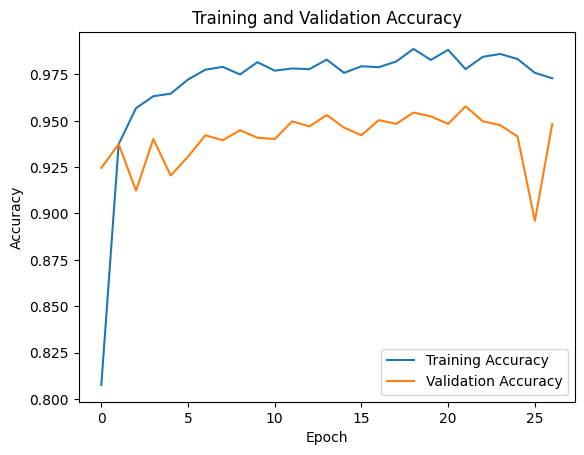

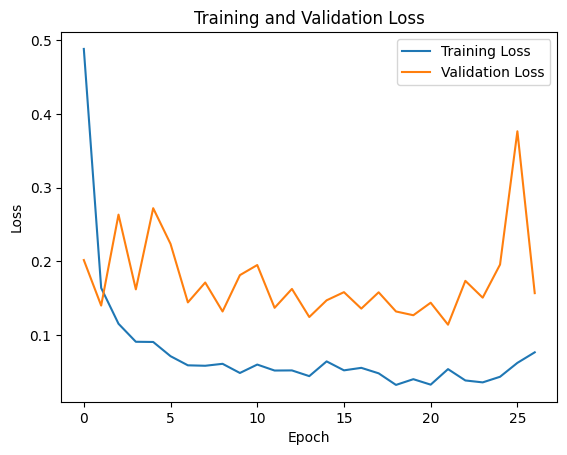

In [15]:
# TODO:
# Plot the training and validation accuracy.
# Plot the training and validation loss.

# <-- Enter your code here <--#

plt.figure()
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.title("Training and Validation Accuracy")
plt.show()

plt.figure()
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.title("Training and Validation Loss")
plt.show()


## 7. Evaluate the Baseline Keras Model


93/93 [==============================] - 0s 576us/step
Test accuracy: 0.9355276552426196
                    precision    recall  f1-score   support

           WALKING       0.92      0.98      0.95       496
  WALKING_UPSTAIRS       0.94      0.92      0.93       471
WALKING_DOWNSTAIRS       0.97      0.93      0.95       420
           SITTING       0.96      0.86      0.91       491
          STANDING       0.85      0.96      0.90       532
            LAYING       1.00      0.95      0.98       537

          accuracy                           0.94      2947
         macro avg       0.94      0.93      0.94      2947
      weighted avg       0.94      0.94      0.94      2947



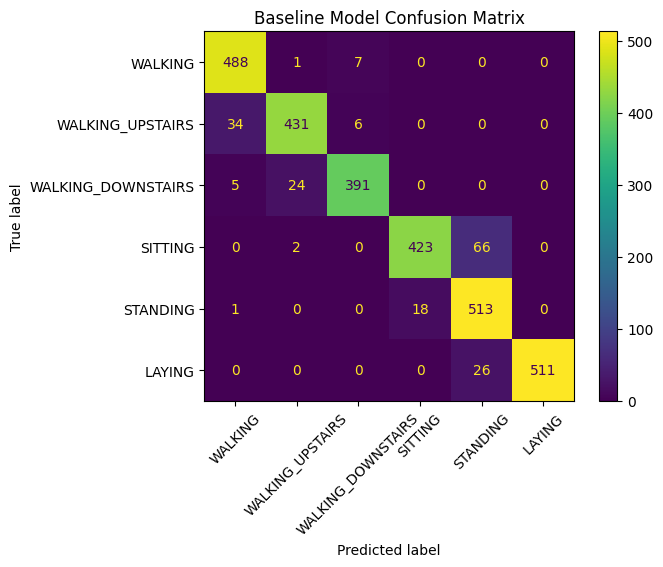

In [16]:
# TODO:
# 1. Obtain predicted probabilities on X_test
# 2. Convert them to class predictions using argmax
# 3. Compute test accuracy
# 4. Print the classification report
# 5. Plot the confusion matrix

# <-- Enter your code here <--#

# 1. Predicted probabilities
y_prob = baseline_model.predict(X_test)

# 2. Convert probabilities to predicted class labels
y_pred = np.argmax(y_prob, axis=1)

# 3. Compute test accuracy
test_accuracy = accuracy_score(y_test, y_pred)
print("Test accuracy:", test_accuracy)

# 4. Classification report
print(classification_report(y_test, y_pred, target_names=class_names))

# 5. Confusion matrix
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

disp.plot(xticks_rotation=45)
plt.title("Baseline Model Confusion Matrix")
plt.show()


## 8. TensorFlow Lite Utilities

The following helper functions are used to:
- convert Keras models to TensorFlow Lite,
- evaluate TensorFlow Lite models on the test set, and
- measure model file size.


In [17]:
def save_binary_model(model_content, filename):
    with open(filename, "wb") as f:
        f.write(model_content)
    return os.path.getsize(filename) / 1024.0  # KB

def representative_dataset_gen():
    for i in range(300):
        sample = X_train[i:i+1].astype(np.float32)
        yield [sample]

def evaluate_tflite_model(tflite_model, X, y_true):
    interpreter = tf.lite.Interpreter(model_content=tflite_model)
    interpreter.allocate_tensors()

    input_details = interpreter.get_input_details()[0]
    output_details = interpreter.get_output_details()[0]

    input_scale, input_zero_point = input_details["quantization"]
    output_scale, output_zero_point = output_details["quantization"]

    y_pred = []

    for i in range(len(X)):
        x = X[i:i+1].astype(np.float32)

        # TODO:
        # Quantize the input only when the input dtype is int8 or uint8.
        # Otherwise keep the input in the required floating-point dtype.

        # <-- Enter your code here <--#

        if input_details["dtype"] == np.int8 or input_details["dtype"] == np.uint8:
            x = x / input_scale + input_zero_point
            x = np.round(x).astype(input_details["dtype"])
        else:
            x = x.astype(input_details["dtype"])

        interpreter.set_tensor(input_details["index"], x)
        interpreter.invoke()

        output = interpreter.get_tensor(output_details["index"])

        # TODO:
        # If the output is quantized, dequantize it back to float32.

        # <-- Enter your code here <--#

        if output_details["dtype"] == np.int8 or output_details["dtype"] == np.uint8:
            output = output_scale * (output.astype(np.float32) - output_zero_point)

        y_pred.append(np.argmax(output, axis=1)[0])

    y_pred = np.array(y_pred)
    acc = accuracy_score(y_true, y_pred)
    return acc, y_pred

def convert_to_tflite_fp32(model):
    converter = tf.lite.TFLiteConverter.from_keras_model(model)
    return converter.convert()

def convert_to_tflite_dynamic_range(model):
    converter = tf.lite.TFLiteConverter.from_keras_model(model)
    converter.optimizations = [tf.lite.Optimize.DEFAULT]
    return converter.convert()

def convert_to_tflite_float16(model):
    converter = tf.lite.TFLiteConverter.from_keras_model(model)
    converter.optimizations = [tf.lite.Optimize.DEFAULT]
    converter.target_spec.supported_types = [tf.float16]
    return converter.convert()

def convert_to_tflite_int8(model):
    converter = tf.lite.TFLiteConverter.from_keras_model(model)
    converter.optimizations = [tf.lite.Optimize.DEFAULT]
    converter.representative_dataset = representative_dataset_gen
    converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
    converter.inference_input_type = tf.int8
    converter.inference_output_type = tf.int8
    return converter.convert()


## 9. Post-Training Quantization (PTQ)


In [18]:
# TODO:
# Convert the baseline model into:
# - FP32 TFLite
# - dynamic range TFLite
# - float16 TFLite
# - int8 TFLite

# Save each model to disk and record its size in KB.
# Evaluate each TFLite model on the test set.

# <-- Enter your code here <--#

tflite_results = []

models = {
    "FP32": convert_to_tflite_fp32(baseline_model),
    "Dynamic Range": convert_to_tflite_dynamic_range(baseline_model),
    "Float16": convert_to_tflite_float16(baseline_model),
    "Int8": convert_to_tflite_int8(baseline_model)
}

for name, tflite_model in models.items():
    filename = name.lower().replace(" ", "_") + ".tflite"

    size_kb = save_binary_model(tflite_model, filename)
    acc, y_pred = evaluate_tflite_model(tflite_model, X_test, y_test)

    tflite_results.append({
        "model": name,
        "size_kb": size_kb,
        "test_accuracy": acc
    })

ptq_results_df = pd.DataFrame(tflite_results)
ptq_results_df

INFO:tensorflow:Assets written to: /var/folders/gs/jmwv5lld4h7b_3jtg80qcvcw0000gn/T/tmpxkjtp1tm/assets


INFO:tensorflow:Assets written to: /var/folders/gs/jmwv5lld4h7b_3jtg80qcvcw0000gn/T/tmpxkjtp1tm/assets
2026-04-23 17:15:24.499880: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-04-23 17:15:24.500213: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-04-23 17:15:24.502330: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /var/folders/gs/jmwv5lld4h7b_3jtg80qcvcw0000gn/T/tmpxkjtp1tm
2026-04-23 17:15:24.502809: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-04-23 17:15:24.502813: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /var/folders/gs/jmwv5lld4h7b_3jtg80qcvcw0000gn/T/tmpxkjtp1tm
2026-04-23 17:15:24.505604: I tensorflow/compiler/mlir/mlir_graph_optimization_pass.cc:382] MLIR V1 optimization pass is not enabled
2026-04-23 17:15:24.507931: I tensorflow/cc/saved_model/load

INFO:tensorflow:Assets written to: /var/folders/gs/jmwv5lld4h7b_3jtg80qcvcw0000gn/T/tmpj4kpd3el/assets



2026-04-23 17:15:24.555761: I tensorflow/cc/saved_model/loader.cc:316] SavedModel load for tags { serve }; Status: success: OK. Took 53428 microseconds.
2026-04-23 17:15:24.580069: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
INFO:tensorflow:Assets written to: /var/folders/gs/jmwv5lld4h7b_3jtg80qcvcw0000gn/T/tmpj4kpd3el/assets
2026-04-23 17:15:24.894144: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-04-23 17:15:24.894154: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-04-23 17:15:24.894251: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /var/folders/gs/jmwv5lld4h7b_3jtg80qcvcw0000gn/T/tmpj4kpd3el
2026-04-23 17:15:24.894700: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-04-23 17:15:24.894704: I tenso

INFO:tensorflow:Assets written to: /var/folders/gs/jmwv5lld4h7b_3jtg80qcvcw0000gn/T/tmp5bkrnt8b/assets


INFO:tensorflow:Assets written to: /var/folders/gs/jmwv5lld4h7b_3jtg80qcvcw0000gn/T/tmp5bkrnt8b/assets
2026-04-23 17:15:25.214481: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-04-23 17:15:25.214493: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-04-23 17:15:25.214603: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /var/folders/gs/jmwv5lld4h7b_3jtg80qcvcw0000gn/T/tmp5bkrnt8b
2026-04-23 17:15:25.215045: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-04-23 17:15:25.215049: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /var/folders/gs/jmwv5lld4h7b_3jtg80qcvcw0000gn/T/tmp5bkrnt8b
2026-04-23 17:15:25.216179: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-04-23 17:15:25.237267: I tensorflow/cc/saved_model/loader.cc:217] Running initialization

INFO:tensorflow:Assets written to: /var/folders/gs/jmwv5lld4h7b_3jtg80qcvcw0000gn/T/tmpa02ohi4w/assets


INFO:tensorflow:Assets written to: /var/folders/gs/jmwv5lld4h7b_3jtg80qcvcw0000gn/T/tmpa02ohi4w/assets
/Users/yutao/ai/projects/tinyml-arduino/lib/python3.11/site-packages/tensorflow/lite/python/convert.py:947: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(
2026-04-23 17:15:25.587780: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-04-23 17:15:25.587792: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-04-23 17:15:25.587916: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /var/folders/gs/jmwv5lld4h7b_3jtg80qcvcw0000gn/T/tmpa02ohi4w
2026-04-23 17:15:25.588480: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-04-23 17:15:25.588485: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /var/folders/gs/jmwv5lld4h7b_3j

,model,size_kb,test_accuracy
0,FP32,726.718750,0.935528
1,Dynamic Range,186.109375,0.935188
2,Float16,365.710938,0.935528
3,Int8,185.335938,0.935528


## 10. PTQ Comparison: Accuracy and Model Size


In [19]:
# TODO:
# Create a comparison DataFrame containing:
# Model Family, Format, Test Accuracy, Model Size (KB)

# <-- Enter your code here <--#

comparison_df = pd.DataFrame({
    "Model Family": ["Baseline DNN"] * len(ptq_results_df),
    "Format": ptq_results_df["model"],
    "Test Accuracy": ptq_results_df["test_accuracy"],
    "Model Size (KB)": ptq_results_df["size_kb"]
})

comparison_df

,Model Family,Format,Test Accuracy,Model Size (KB)
0,Baseline DNN,FP32,0.935528,726.718750
1,Baseline DNN,Dynamic Range,0.935188,186.109375
2,Baseline DNN,Float16,0.935528,365.710938
3,Baseline DNN,Int8,0.935528,185.335938


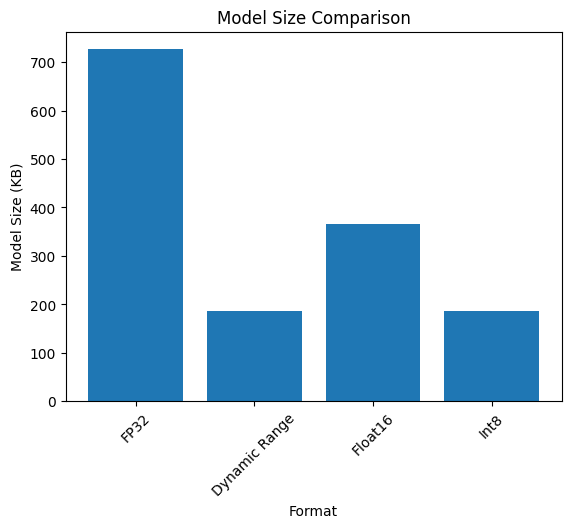

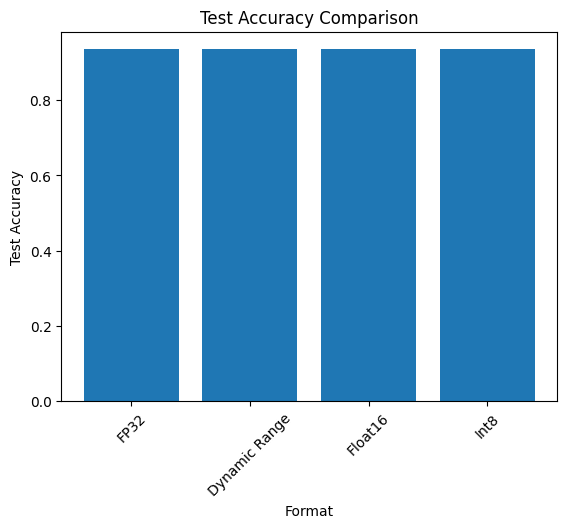

In [20]:
# TODO:
# Create one bar plot for model size and another for test accuracy.

# <-- Enter your code here <--#

plt.figure()
plt.bar(comparison_df["Format"], comparison_df["Model Size (KB)"])
plt.xlabel("Format")
plt.ylabel("Model Size (KB)")
plt.title("Model Size Comparison")
plt.xticks(rotation=45)
plt.show()

plt.figure()
plt.bar(comparison_df["Format"], comparison_df["Test Accuracy"])
plt.xlabel("Format")
plt.ylabel("Test Accuracy")
plt.title("Test Accuracy Comparison")
plt.xticks(rotation=45)
plt.show()

### Confusion Matrix for the PTQ Int8 Model


PTQ INT8 Test Accuracy: 0.9355276552426196
                    precision    recall  f1-score   support

           WALKING       0.92      0.98      0.95       496
  WALKING_UPSTAIRS       0.94      0.91      0.93       471
WALKING_DOWNSTAIRS       0.97      0.93      0.95       420
           SITTING       0.96      0.86      0.91       491
          STANDING       0.85      0.97      0.90       532
            LAYING       1.00      0.95      0.98       537

          accuracy                           0.94      2947
         macro avg       0.94      0.93      0.94      2947
      weighted avg       0.94      0.94      0.94      2947



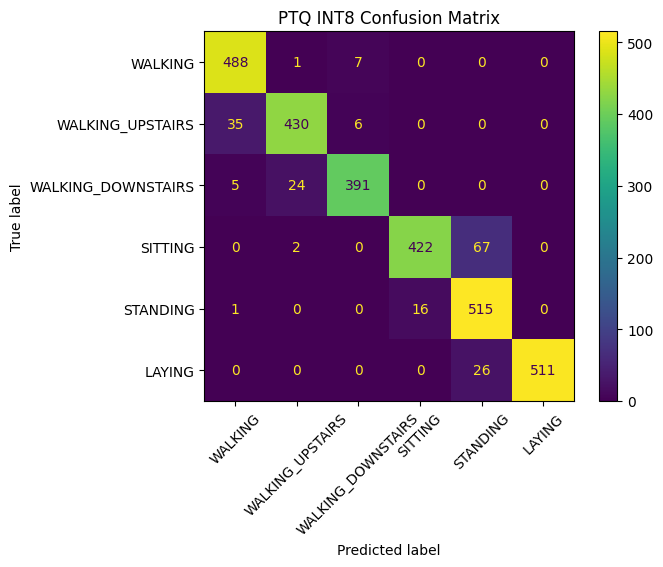

In [21]:
# TODO:
# Plot the confusion matrix for the PTQ int8 model.
# Print the classification report for the PTQ int8 model.

# <-- Enter your code here <--#

int8_model = models["Int8"]

int8_acc, int8_y_pred = evaluate_tflite_model(
    int8_model,
    X_test,
    y_test
)

print("PTQ INT8 Test Accuracy:", int8_acc)

print(classification_report(
    y_test,
    int8_y_pred,
    target_names=class_names
))

cm = confusion_matrix(y_test, int8_y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

disp.plot(xticks_rotation=45)
plt.title("PTQ INT8 Confusion Matrix")
plt.show()


## 11. Quantization-Aware Training (QAT)

QAT simulates quantization effects during training so that the final model is usually more robust after conversion to int8.


In [22]:
# TODO:
# Create a QAT model from the trained baseline model using TF-MOT.
# Compile it with Adam(1e-4), sparse_categorical_crossentropy, and accuracy.

# <-- Enter your code here <--#

import tensorflow_model_optimization as tfmot

qat_model = tfmot.quantization.keras.quantize_model(baseline_model)

qat_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)


### Fine-Tune the QAT Model


In [23]:
# TODO:
# Fine-tune the QAT model for 8 epochs using validation_split=0.2 and batch_size=64.

# <-- Enter your code here <--#

qat_history = qat_model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=8,
    batch_size=64
)


Epoch 1/8
92/92 [==============================] - 1s 4ms/step - loss: 0.0297 - accuracy: 0.9903 - val_loss: 0.1238 - val_accuracy: 0.9565
Epoch 2/8
92/92 [==============================] - 0s 2ms/step - loss: 0.0249 - accuracy: 0.9912 - val_loss: 0.1274 - val_accuracy: 0.9579
Epoch 3/8
92/92 [==============================] - 0s 2ms/step - loss: 0.0244 - accuracy: 0.9918 - val_loss: 0.1236 - val_accuracy: 0.9572
Epoch 4/8
92/92 [==============================] - 0s 2ms/step - loss: 0.0218 - accuracy: 0.9918 - val_loss: 0.1258 - val_accuracy: 0.9585
Epoch 5/8
92/92 [==============================] - 0s 2ms/step - loss: 0.0202 - accuracy: 0.9930 - val_loss: 0.1460 - val_accuracy: 0.9531
Epoch 6/8
92/92 [==============================] - 0s 2ms/step - loss: 0.0219 - accuracy: 0.9913 - val_loss: 0.1471 - val_accuracy: 0.9565
Epoch 7/8
92/92 [==============================] - 0s 2ms/step - loss: 0.0196 - accuracy: 0.9935 - val_loss: 0.1357 - val_accuracy: 0.9572
Epoch 8/8
92/92 [==========

### Evaluate the QAT Keras Model


In [24]:
# TODO:
# Evaluate the QAT Keras model on X_test.
# Print the test accuracy and classification report.

# <-- Enter your code here <--#

qat_prob = qat_model.predict(X_test)
qat_pred = np.argmax(qat_prob, axis=1)

qat_test_accuracy = accuracy_score(y_test, qat_pred)
print("QAT Keras Test Accuracy:", qat_test_accuracy)

print(classification_report(
    y_test,
    qat_pred,
    target_names=class_names
))


93/93 [==============================] - 0s 519us/step
QAT Keras Test Accuracy: 0.9385816084153377
                    precision    recall  f1-score   support

           WALKING       0.93      0.99      0.96       496
  WALKING_UPSTAIRS       0.94      0.92      0.93       471
WALKING_DOWNSTAIRS       0.97      0.93      0.95       420
           SITTING       0.96      0.87      0.91       491
          STANDING       0.85      0.97      0.91       532
            LAYING       1.00      0.96      0.98       537

          accuracy                           0.94      2947
         macro avg       0.94      0.94      0.94      2947
      weighted avg       0.94      0.94      0.94      2947



### Convert the QAT Model to Int8 TensorFlow Lite


In [25]:
# TODO:
# Convert the QAT model to int8 TensorFlow Lite.
# Save the model, compute its size, and evaluate it on the test set.

# <-- Enter your code here <--#

qat_int8_tflite = convert_to_tflite_int8(qat_model)

qat_int8_size_kb = save_binary_model(
    qat_int8_tflite,
    "qat_int8.tflite"
)

qat_int8_accuracy, qat_int8_pred = evaluate_tflite_model(
    qat_int8_tflite,
    X_test,
    y_test
)

print("QAT INT8 Model Size (KB):", qat_int8_size_kb)
print("QAT INT8 Test Accuracy:", qat_int8_accuracy)

INFO:tensorflow:Assets written to: /var/folders/gs/jmwv5lld4h7b_3jtg80qcvcw0000gn/T/tmpm2is_h90/assets


INFO:tensorflow:Assets written to: /var/folders/gs/jmwv5lld4h7b_3jtg80qcvcw0000gn/T/tmpm2is_h90/assets
/Users/yutao/ai/projects/tinyml-arduino/lib/python3.11/site-packages/tensorflow/lite/python/convert.py:947: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(
2026-04-23 17:18:43.219866: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-04-23 17:18:43.219884: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-04-23 17:18:43.220189: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /var/folders/gs/jmwv5lld4h7b_3jtg80qcvcw0000gn/T/tmpm2is_h90
2026-04-23 17:18:43.226097: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-04-23 17:18:43.226107: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /var/folders/gs/jmwv5lld4h7b_3j

QAT INT8 Model Size (KB): 185.6953125
QAT INT8 Test Accuracy: 0.9389209365456397


## 12. PTQ Int8 vs QAT Int8


In [26]:
# TODO:
# Create a DataFrame comparing PTQ int8 and QAT int8:
# Model, Test Accuracy, Model Size (KB)

# <-- Enter your code here <--#

ptq_vs_qat_df = pd.DataFrame({
    "Model": ["PTQ INT8", "QAT INT8"],
    "Test Accuracy": [models["Int8"] and ptq_results_df.loc[ptq_results_df["model"] == "Int8", "test_accuracy"].values[0],
                      qat_int8_accuracy],
    "Model Size (KB)": [ptq_results_df.loc[ptq_results_df["model"] == "Int8", "size_kb"].values[0],
                        qat_int8_size_kb]
})

ptq_vs_qat_df


,Model,Test Accuracy,Model Size (KB)
0,PTQ INT8,0.935528,185.335938
1,QAT INT8,0.938921,185.695312


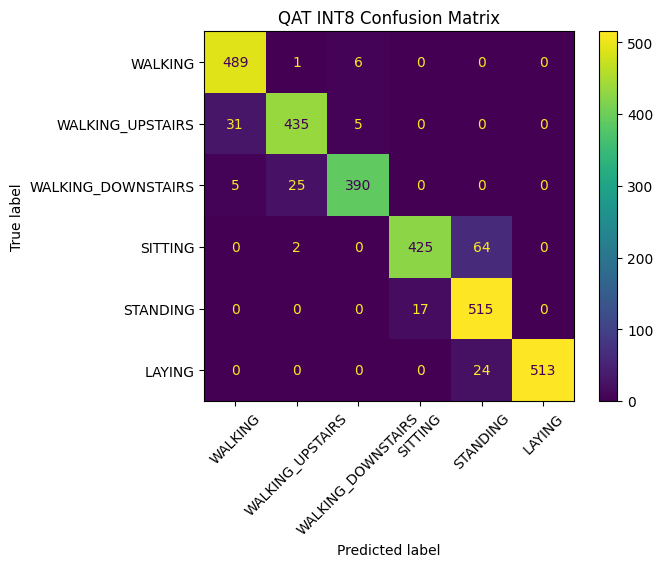

In [27]:
# TODO:
# Plot the confusion matrix for the QAT int8 model.

# <-- Enter your code here <--#

cm = confusion_matrix(y_test, qat_int8_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

disp.plot(xticks_rotation=45)
plt.title("QAT INT8 Confusion Matrix")
plt.show()


## 13. Summary Questions

Write short answers to the following:
1. Which quantization method gave the smallest model size?
   
   The INT8 quantization both PTQ and QAT produced the smallest model size, around 185 KB, which is significantly smaller than FP32 and Float16.
2. Which quantization method gave the best accuracy among the TensorFlow Lite models?
   
   The INT8 models achieved the best accuracy among the TFLite models, maintaining performance close to the original FP32 model.
3. Did QAT improve the final int8 model compared with PTQ int8?
   
   Yes. QAT slightly improved accuracy compared to PTQ INT8 because it simulates quantization effects during training, making the model more robust.
4. Why is this dataset a good fit for a DNN-based TinyML workflow?
   
   This dataset is a good fit for a DNN-based TinyML workflow because it uses numerical sensor features instead of complex data like images or audio, making      it lightweight and efficient to process. It also has a moderate number of features, which allows the model to remain small and suitable for resource-          constrained devices. Additionally, the task of human activity recognition requires real-time classification, which aligns well with the goals of TinyML        systems.
5. If you were deploying this model on a resource-constrained device, which version would you choose and why?
   
   I would choose the QAT INT8 model for deployment on a resource-constrained device. It has a small model size of about 185 KB, while still keeping high         accuracy close to the FP32 model. It also uses efficient integer-only inference, which makes it better for low-power microcontrollers.


## 14. Submission Requirements

Submit the following:
- your completed notebook,
- the generated `.tflite` files,
- screenshots or output cells showing the final comparison table,
- confusion matrices for the baseline model and the final int8 model you want to highlight,
- and short written observations answering the summary questions.

Make sure your notebook runs from top to bottom without errors.
